<a href="https://colab.research.google.com/github/bavinkdevadas-hub/ML-Projects/blob/main/Cervical%20Cancer%20Risk%20Prediction%20System/Cervical_Cancer_Risk_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Problem statement

With the cervical cancer diagnosis/risk indicator as the prediction variable, the task involves using patient demographic, medical history, lifestyle, and behavioral features to predict whether a patient is at risk of cervical cancer. This can be approached as a binary classification problem, where the model learns patterns from the available patient data to predict the likelihood of cervical cancer.

Cervical cancer is one of the most common cancers affecting women worldwide, but early detection and timely treatment can significantly improve outcomes. Identifying individuals who may be at higher risk can support early screening, preventive care, and better healthcare decision-making.

The objective of this project is to develop a predictive machine learning model that analyzes relevant patient information and determines the likelihood of cervical cancer risk. The system aims to serve as an assistive predictive tool for identifying high-risk cases and supporting proactive screening and preventive healthcare strategies.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/cervical_cancer_synthetic_50000_best_effort (1).csv")
df

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,21,2,16,1,0,0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,35,4,18,0,0,0,0,1,2,0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,15,1,15,0,0,0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,31,3,16,4,1,10,1,0,0,0,...,NaN,NaN,0,0,0,0,0,0,0,0
4,17,1,15,2,0,0,0,1,0,0,...,2.0,2.0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,15,2,13,0,0,0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,0,0
49996,35,3,17,4,0,0,0,1,7,1,...,19.0,19.0,0,0,0,0,0,0,0,0
49997,35,2,17,3,0,0,0,1,1,0,...,NaN,NaN,0,0,0,0,1,1,0,1
49998,30,4,19,1,0,0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 50000 non-null  int64  
 1   Number of sexual partners           50000 non-null  int64  
 2   First sexual intercourse            50000 non-null  int64  
 3   Num of pregnancies                  50000 non-null  int64  
 4   Smokes                              50000 non-null  int64  
 5   Smokes (years)                      50000 non-null  int64  
 6   Smokes (packs/year)                 50000 non-null  int64  
 7   Hormonal Contraceptives             50000 non-null  int64  
 8   Hormonal Contraceptives (years)     50000 non-null  int64  
 9   IUD                                 50000 non-null  int64  
 10  IUD (years)                         50000 non-null  int64  
 11  STDs                                50000

In [ ]:
df.isnull().sum()


,0
Age,0
Number of sexual partners,0
First sexual intercourse,0
Num of pregnancies,0
Smokes,0
Smokes (years),0
Smokes (packs/year),0
Hormonal Contraceptives,0
Hormonal Contraceptives (years),0
IUD,0


In [ ]:
df.drop(columns=["STDs: Time since first diagnosis",'STDs: Time since last diagnosis'],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Age                                 50000 non-null  int64
 1   Number of sexual partners           50000 non-null  int64
 2   First sexual intercourse            50000 non-null  int64
 3   Num of pregnancies                  50000 non-null  int64
 4   Smokes                              50000 non-null  int64
 5   Smokes (years)                      50000 non-null  int64
 6   Smokes (packs/year)                 50000 non-null  int64
 7   Hormonal Contraceptives             50000 non-null  int64
 8   Hormonal Contraceptives (years)     50000 non-null  int64
 9   IUD                                 50000 non-null  int64
 10  IUD (years)                         50000 non-null  int64
 11  STDs                                50000 non-null  int64
 12  STDs

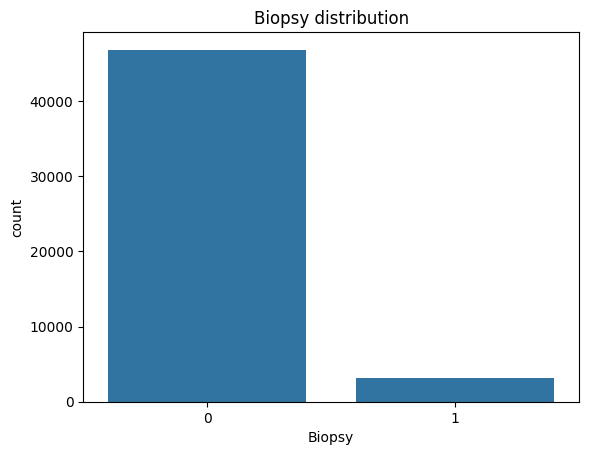

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Biopsy', data=df)
plt.title('Biopsy distribution')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Separate features and target
x = df.drop(columns=['Biopsy'])
y = df['Biopsy']


# Apply SMOTE
smote = SMOTE(random_state=42)
x_res, y_res = smote.fit_resample(x, y)

# Combine into one DataFrame
df_smote = pd.DataFrame(x_res, columns=x.columns)
df_smote['Biopsy'] = y_res

In [ ]:
df=df_smote

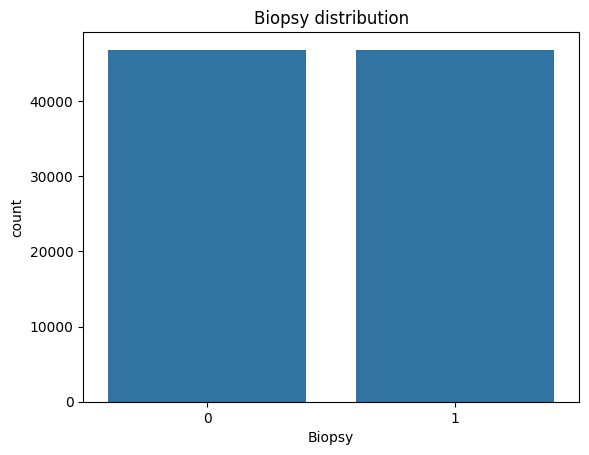

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Biopsy', data=df)
plt.title('Biopsy distribution')
plt.show()

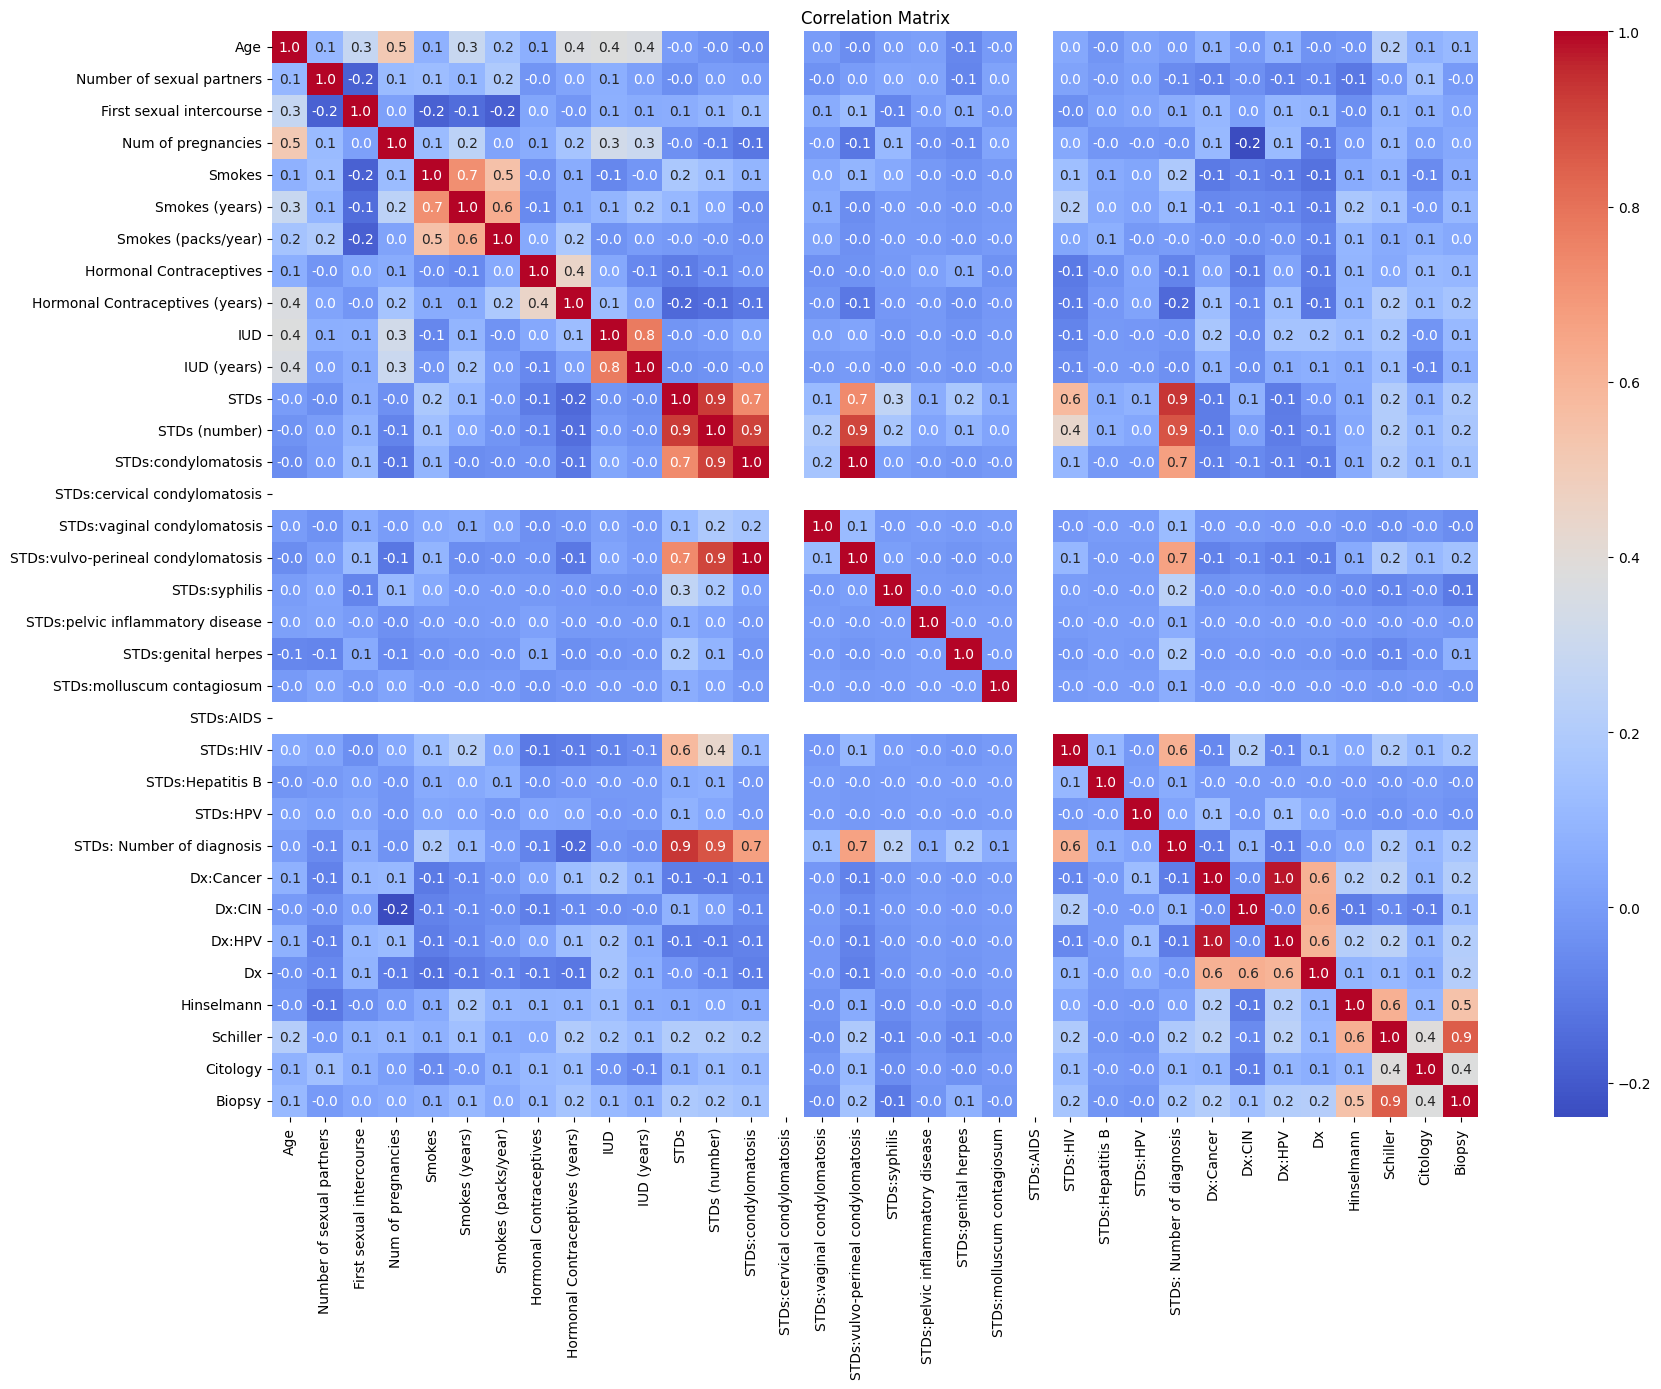

In [ ]:
# Correlation matrix
corr_matrix=df.corr()
# Heatmap of correlation matrix
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix,annot=True,fmt="0.01f",cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93674 entries, 0 to 93673
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Age                                 93674 non-null  int64
 1   Number of sexual partners           93674 non-null  int64
 2   First sexual intercourse            93674 non-null  int64
 3   Num of pregnancies                  93674 non-null  int64
 4   Smokes                              93674 non-null  int64
 5   Smokes (years)                      93674 non-null  int64
 6   Smokes (packs/year)                 93674 non-null  int64
 7   Hormonal Contraceptives             93674 non-null  int64
 8   Hormonal Contraceptives (years)     93674 non-null  int64
 9   IUD                                 93674 non-null  int64
 10  IUD (years)                         93674 non-null  int64
 11  STDs                                93674 non-null  int64
 12  STDs

In [ ]:
df=df.drop(columns=['STDs:cervical condylomatosis', 'STDs:AIDS'])

In [ ]:
drop_cols = [
    "STDs",
    "STDs: Number of diagnosis",
    "IUD",
    "Smokes",
    "Dx"
]

df = df.drop(columns=drop_cols)

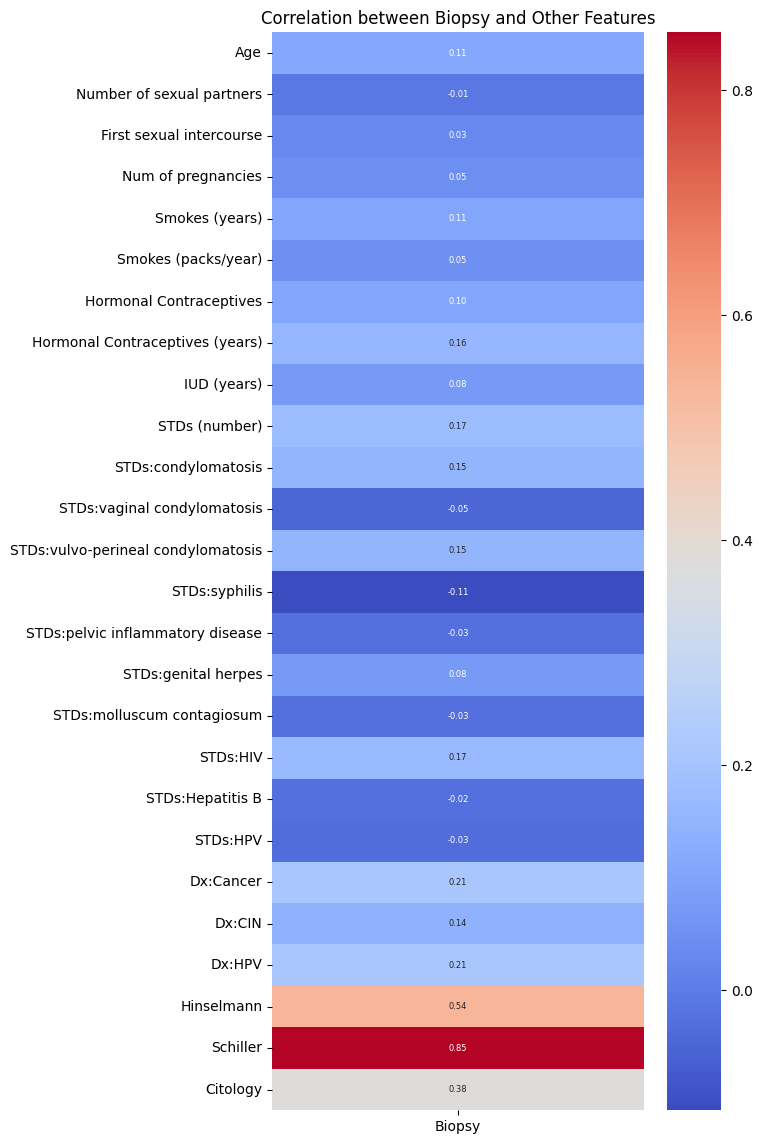

In [ ]:
# Calculate the correlation between 'Biopsy' and all other columns
loan_status_corr=df.corr()['Biopsy']

# Remove the correlation of 'Biopsy'with itself (which is always 1)
loan_status_corr=loan_status_corr.drop('Biopsy')
# Create a heatmap to visualize the correlations
plt.figure(figsize=(6, 14))
sns.heatmap(loan_status_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',
            cbar=True,annot_kws={'size':6}) # to_frame() converts Series to DataFrame for heatmap
plt.title('Correlation between Biopsy and Other Features')
plt.show()

In [ ]:
df = df.drop(columns=[
    "Number of sexual partners",      # -0.01
    "First sexual intercourse",       # 0.03
    "STDs:vaginal condylomatosis",    # -0.05
    "STDs:pelvic inflammatory disease", # -0.03
    "STDs:molluscum contagiosum",     # -0.03
    "STDs:Hepatitis B",               # -0.02
    "STDs:HPV"                        # -0.03
])

In [ ]:
df = df.drop(columns=[
    'Dx:Cancer',
    'Dx:CIN',
    'Dx:HPV',
    'Hinselmann',
    'Schiller',
    'Citology'
])

<Axes: >

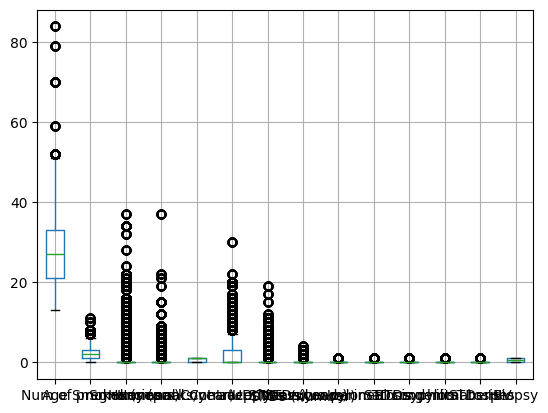

In [ ]:
df.boxplot()

In [ ]:
# Function to remove outliers using the IQR method except for one column
def remove_outliers_iqr(df,exclude_column):


  for col in df.columns:

   # Skip the specified column
    if col==exclude_column:
      continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    # Filter the DataFrame to remove rows with outliers in each column
    df=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]
  return df


# Specify the column to exclude
df_cleaned=remove_outliers_iqr(df,exclude_column="Biopsy")
df=df_cleaned

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52661 entries, 0 to 93671
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Age                                 52661 non-null  int64
 1   Num of pregnancies                  52661 non-null  int64
 2   Smokes (years)                      52661 non-null  int64
 3   Smokes (packs/year)                 52661 non-null  int64
 4   Hormonal Contraceptives             52661 non-null  int64
 5   Hormonal Contraceptives (years)     52661 non-null  int64
 6   IUD (years)                         52661 non-null  int64
 7   STDs (number)                       52661 non-null  int64
 8   STDs:condylomatosis                 52661 non-null  int64
 9   STDs:vulvo-perineal condylomatosis  52661 non-null  int64
 10  STDs:syphilis                       52661 non-null  int64
 11  STDs:genital herpes                 52661 non-null  int64
 12  STDs:HIV 

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
 #Select the features that you want to scale
features = [
    'Age',
    'Num of pregnancies',
    'Smokes (years)',
    'Smokes (packs/year)',
    'Hormonal Contraceptives',
    'Hormonal Contraceptives (years)',
    'IUD (years)',
    'STDs (number)',
    'STDs:condylomatosis',
    'STDs:vulvo-perineal condylomatosis',
    'STDs:syphilis',
    'STDs:genital herpes',
    'STDs:HIV'
]
# Create a MinMaxScaler object
scaler = MinMaxScaler()
# Fit the scaler to your data and transform it
scaled_data = scaler.fit_transform(df[features])
# Create a DataFrame from scaled_data with the correct column names
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=scaled_df
y=df["Biopsy"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
# Train a baseline logistic regression model
model=LogisticRegression()
model.fit(x_train,y_train)
# Predict and evaluate the model
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"baseline model accuracy:{accuracy:.2f}")

baseline model accuracy:0.61


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9635424578459669


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9635424578459669


In [ ]:
from xgboost import XGBClassifier
model=XGBClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9635424578459669


In [ ]:
from sklearn.model_selection import StratifiedKFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()
#track best fold data
best_accuracy=0
best_fold=-1

# Save best fold's data
best_x_train = None
best_y_train = None
best_x_test = None
best_y_test = None
best_y_pred = None

# Loop over each fold
for fold, (train_index, test_index) in enumerate(kf.split(x), 1):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    model.fit(x_train, y_train)

    # Predict
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    # Update best fold
    if acc > best_accuracy:
      best_accuracy = acc
      best_fold = fold
      best_x_train = x_train
      best_y_train = y_train
      best_x_test = x_test
      best_y_test = y_test
      best_y_pred = y_pred
 # Output best fold details
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.6093230798442989
Fold 2 Accuracy: 0.6109001139384732
Fold 3 Accuracy: 0.6151728066843904
Fold 4 Accuracy: 0.5995062666160274
Fold 5 Accuracy: 0.6303646031143183

 Best Fold: 5 with Accuracy: 0.6303646031143183


In [ ]:
model = LogisticRegression()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.6303646031143183

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.9616407140144322

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.9616407140144322

In [ ]:
from xgboost import XGBClassifier
model=XGBClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.9616407140144322

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model=AdaBoostClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.6049183440941891

In [ ]:
print(x.columns.tolist())

['Age', 'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STDs (number)', 'STDs:condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:genital herpes', 'STDs:HIV']


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Defining the ANN model
model = Sequential()
model.add(Dense(64, input_shape=(13,),activation='relu'))  # Hidden Layer 1
model.add(Dense(32, activation='relu'))# Hidden Layer 2
model.add(Dense(1, activation='sigmoid'))             # Output Layer

# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 3. Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Training the model
model.fit(best_x_train, best_y_train, epochs=17, batch_size=32)

Epoch 1/17
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6692 - loss: 0.5907
Epoch 2/17
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7871 - loss: 0.4493
Epoch 3/17
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8370 - loss: 0.3738
Epoch 4/17
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8605 - loss: 0.3268
Epoch 5/17
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8729 - loss: 0.2959
Epoch 6/17
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8862 - loss: 0.2687
Epoch 7/17
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8996 - loss: 0.2455
Epoch 8/17
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9051 - loss: 0.2324
Epoch 9/17
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9101 - loss: 0.2205
Epoch 10/17
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9164 - loss: 0.2105
Epoch 11/17
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9186 - loss: 0.2035
Epoch 12/17
1317/1317 ━━━━━━━━

In [ ]:
# Evaluating the model
loss, accuracy = model.evaluate( best_x_test, best_y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9402 - loss: 0.1635
Model Accuracy: 94.02%


##Conclusion

This project successfully developed a machine learning-based system for predicting cervical cancer biopsy outcomes using demographic, behavioral, and clinical risk factors. The dataset was preprocessed by handling data quality issues, reducing multicollinearity, and removing diagnostic features that could cause data leakage. Multiple machine learning algorithms were evaluated to identify the most effective approach for the prediction task.

Among the models tested, Random Forest achieved an accuracy of 96.16%, demonstrating strong predictive performance on the dataset. The results show that machine learning can effectively identify patterns associated with cervical cancer risk and may be useful as a supportive tool for early risk assessment. However, the model is intended for analytical and decision-support purposes and should not replace professional medical diagnosis.